In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [ ]:
class RateCalculations:
    def __init__(self, mass_DM_list, q_list, omega_list):
        c=2.998e8 #in m/s
        self.mass_DM_list = mass_DM_list
        self.mass_proton = 938.272e6 # eV
        self.density_DM = 0.3e9 #eV/cm^3, plus minus 0.1
        self.density_target = 1.307e33 #eV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500*1000/c 
        self.v_earth = 240*1000/c 
        self.v_disp = 220*1000/c
        self.q_list = q_list
        self.omega_list = omega_list

    def get_v_min(self):
        '''
        v_min: 3d array shape (num of DM mass, num of p, num of omega)
        '''
        omega_list = self.omega_list[np.newaxis, np.newaxis, :] 
        q_list = self.q_list[np.newaxis, :, np.newaxis]
        mass_DM_list = self.mass_DM_list[:, np.newaxis, np.newaxis]
        self.v_min = omega_list/ q_list + q_list / (2 * mass_DM_list)
    
    def _inverse_mean_sol1(self):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * (np.pi**(3/2)) * (sp.special.erf(ratio) - 2*ratio/np.sqrt(np.pi)*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((self.v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((self.v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * (np.pi**(3/2)) * (sp.special.erf(ratio) - 2*ratio*np.sqrt(np.pi)*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(self.v_esc/self.v_disp) 
                                                       - sp.special.erf((self.v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-self.v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral

    def get_inverse_mean_func(self,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        self.inverse_mean_func = np.where(self.v_min>(self.v_esc+self.v_earth), 0, 
                        np.where(self.v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(),
                                self._inverse_mean_sol2()))
    
    def get_scattering_rate(self, s_factor): # 2108.03239 eqn 11
        # eqn for differential rate?? 
        '''
        s_factor
        returns: dR/dq. 2d array (num of DM mass, num of p)
        '''
        reducedMass = self.mass_DM_list* self.mass_proton/(self.mass_DM_list+ self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM_list * reducedMass**2)
        omega_integral = sp.integrate.simpson(self.inverse_mean_func * s_factor, self.omega_list, axis=-1)
        self.scattering_rate = sp.integrate.simpson(omega_integral * constFactor * self.q_list, self.q_list, axis=-1)

    # def _get_omega_integral(self,):
    #     '''
    #     Helper function 
    #     ''' 

    def get_cross_section(self, ):
        return 3/self.scattering_rate # I got this from the 2011_Paper_Scattering.ipynb in this repo dont understand
        


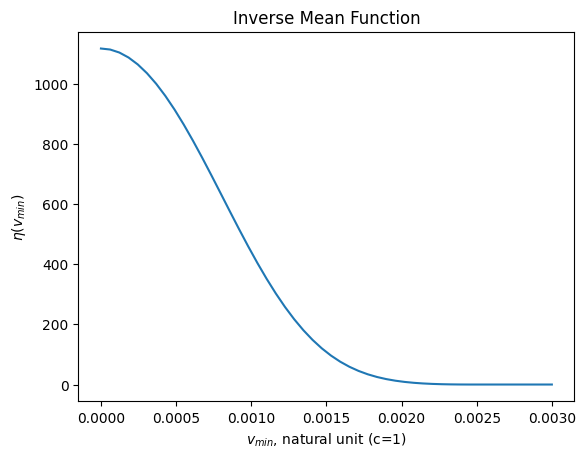

In [3]:
vminlist = np.linspace(0,0.003)
test = RateCalculations(None, None, None)
test.v_min = vminlist
test.get_inverse_mean_func()
eta = test.inverse_mean_func
plt.plot(vminlist,eta)
plt.xlabel("$v_{min}$, natural unit (c=1)")
plt.ylabel(r"$\eta(v_{min})$")
plt.title('Inverse Mean Function')
plt.show()

In [4]:
qlist = np.linspace(0, 75,500)[:, np.newaxis] # 0 ~ 75 keV
max_omega = 150*1e-6 # keV
xlength = 400
omglist = np.linspace(0, max_omega,xlength) 
mass=26161e3
latticeConst=2*np.pi/2.28
# impulse approx
deltasq = qlist**2 * 13.13e-6/(2*mass)
ia =  28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


C:\Users\xylin\AppData\Local\Temp\ipykernel_18796\3129051883.py:9: RuntimeWarning: divide by zero encountered in divide
  ia =  28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)
C:\Users\xylin\AppData\Local\Temp\ipykernel_18796\3129051883.py:9: RuntimeWarning: invalid value encountered in divide
  ia =  28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)
C:\Users\xylin\AppData\Local\Temp\ipykernel_18796\3129051883.py:9: RuntimeWarning: invalid value encountered in multiply
  ia =  28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


In [5]:
vminlist = np.linspace(0,0.003)
partialratecalc = RateCalculations(None, None, None)
